<a href="https://colab.research.google.com/github/SharonAwuor/Machine-Learning/blob/main/Machine_learning(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries

!pip install pandas numpy matplotlib seaborn scikit-learn missingno -q

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from google.colab import files

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdurraziq01/cloud-computing-performance-metrics")

print("Path to dataset files:", path)

100%|██████████| 165M/165M [00:01<00:00, 133MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdurraziq01/cloud-computing-performance-metrics/versions/1


In [4]:
import os

print(path)
print(os.listdir(path))

/root/.cache/kagglehub/datasets/abdurraziq01/cloud-computing-performance-metrics/versions/1
['vmCloud_data.csv']


In [5]:
import os
import glob
import pandas as pd

csv_files = glob.glob(os.path.join(path, "*.csv"))

print("CSV files found:")
print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

CSV files found:
['/root/.cache/kagglehub/datasets/abdurraziq01/cloud-computing-performance-metrics/versions/1/vmCloud_data.csv']


,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting


In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (2000000, 12)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   vm_id                      object 
 1   timestamp                  object 
 2   cpu_usage                  float64
 3   memory_usage               float64
 4   network_traffic            float64
 5   power_consumption          float64
 6   num_executed_instructions  float64
 7   execution_time             float64
 8   energy_efficiency          float64
 9   task_type                  object 
 10  task_priority              object 
 11  task_status                object 
dtypes: float64(7), object(5)
memory usage: 183.1+ MB


In [8]:
df.describe(include='all')

,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
count,1799362,1799334,1.800962e+06,1.799490e+06,1.800519e+06,1.799729e+06,1.800314e+06,1.800173e+06,1.799958e+06,1800038,1800567,1799694
unique,1799362,1708964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3
top,89b1f28f-6134-4ba5-8e9f-8777ba43887a,2023-05-04 16:29:31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,io,medium,waiting
freq,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,600695,600700,600358
mean,NaN,NaN,5.001223e+01,4.998190e+01,5.000076e+02,2.500584e+02,5.001897e+03,4.997133e+01,5.002524e-01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
min,NaN,NaN,7.071203e-05,2.516784e-06,1.890490e-04,1.923802e-04,0.000000e+00,1.036192e-06,1.258445e-07,NaN,NaN,NaN
25%,NaN,NaN,2.497675e+01,2.500378e+01,2.500669e+02,1.249695e+02,2.504000e+03,2.497908e+01,2.501631e-01,NaN,NaN,NaN
50%,NaN,NaN,5.005476e+01,4.997609e+01,5.000076e+02,2.502472e+02,5.002000e+03,4.996407e+01,5.003692e-01,NaN,NaN,NaN
75%,NaN,NaN,7.502934e+01,7.495588e+01,7.498175e+02,3.751069e+02,7.502000e+03,7.497650e+01,7.503617e-01,NaN,NaN,NaN


In [9]:
print(df.columns.tolist())

['vm_id', 'timestamp', 'cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency', 'task_type', 'task_priority', 'task_status']


In [10]:
df.isnull().sum()

,0
vm_id,200638
timestamp,200666
cpu_usage,199038
memory_usage,200510
network_traffic,199481
...,...
execution_time,199827
energy_efficiency,200042
task_type,199962
task_priority,199433


In [11]:
# Make a copy
df_clean = df.copy()

# Remove duplicate rows
print("Duplicate rows before:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

# Convert timestamp
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

# Separate columns
numerical_cols = df_clean.select_dtypes(include=["float64", "int64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object"]).columns

# Fill numerical missing values with median
for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verify
print(df_clean.isnull().sum())

Duplicate rows before: 0
Shape after removing duplicates: (2000000, 12)
vm_id                     0
timestamp            200666
cpu_usage                 0
memory_usage              0
network_traffic           0
                      ...  
execution_time            0
energy_efficiency         0
task_type                 0
task_priority             0
task_status               0
Length: 12, dtype: int64


In [12]:
df_clean.to_csv("cloud_performance_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [13]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,1799334,2023-04-11 07:19:55.175783168,2023-01-01 00:00:09,2023-02-20 04:34:56.249999872,2023-04-11 07:56:02.500000,2023-05-31 10:45:20.249999872,2023-07-20 12:04:18,NaN
cpu_usage,2000000.0,50.016464,0.000071,27.745277,50.054758,72.274666,99.999972,27.402081
memory_usage,2000000.0,49.981316,0.000003,27.771007,49.976089,72.182833,99.999928,27.368729
network_traffic,2000000.0,500.007574,0.000189,277.981755,500.007595,722.093756,999.999837,273.809862
power_consumption,2000000.0,250.077282,0.000192,138.927349,250.247239,361.200741,499.999325,136.944869
num_executed_instructions,2000000.0,5001.907415,0.0,2782.0,5002.0,7226.0,9999.0,2737.424228
execution_time,2000000.0,49.970602,0.000001,27.740942,49.964074,72.190108,99.999992,27.381544
energy_efficiency,2000000.0,0.500264,0.0,0.277678,0.500369,0.722671,1.0,0.27385


In [14]:
df_clean.describe(include="object")

,vm_id,task_type,task_priority,task_status
count,2000000,2000000,2000000,2000000
unique,1799362,3,3,3
top,00001960-0da3-405c-a42a-67e6b4fa05e3,io,medium,waiting
freq,200639,800657,800133,800664


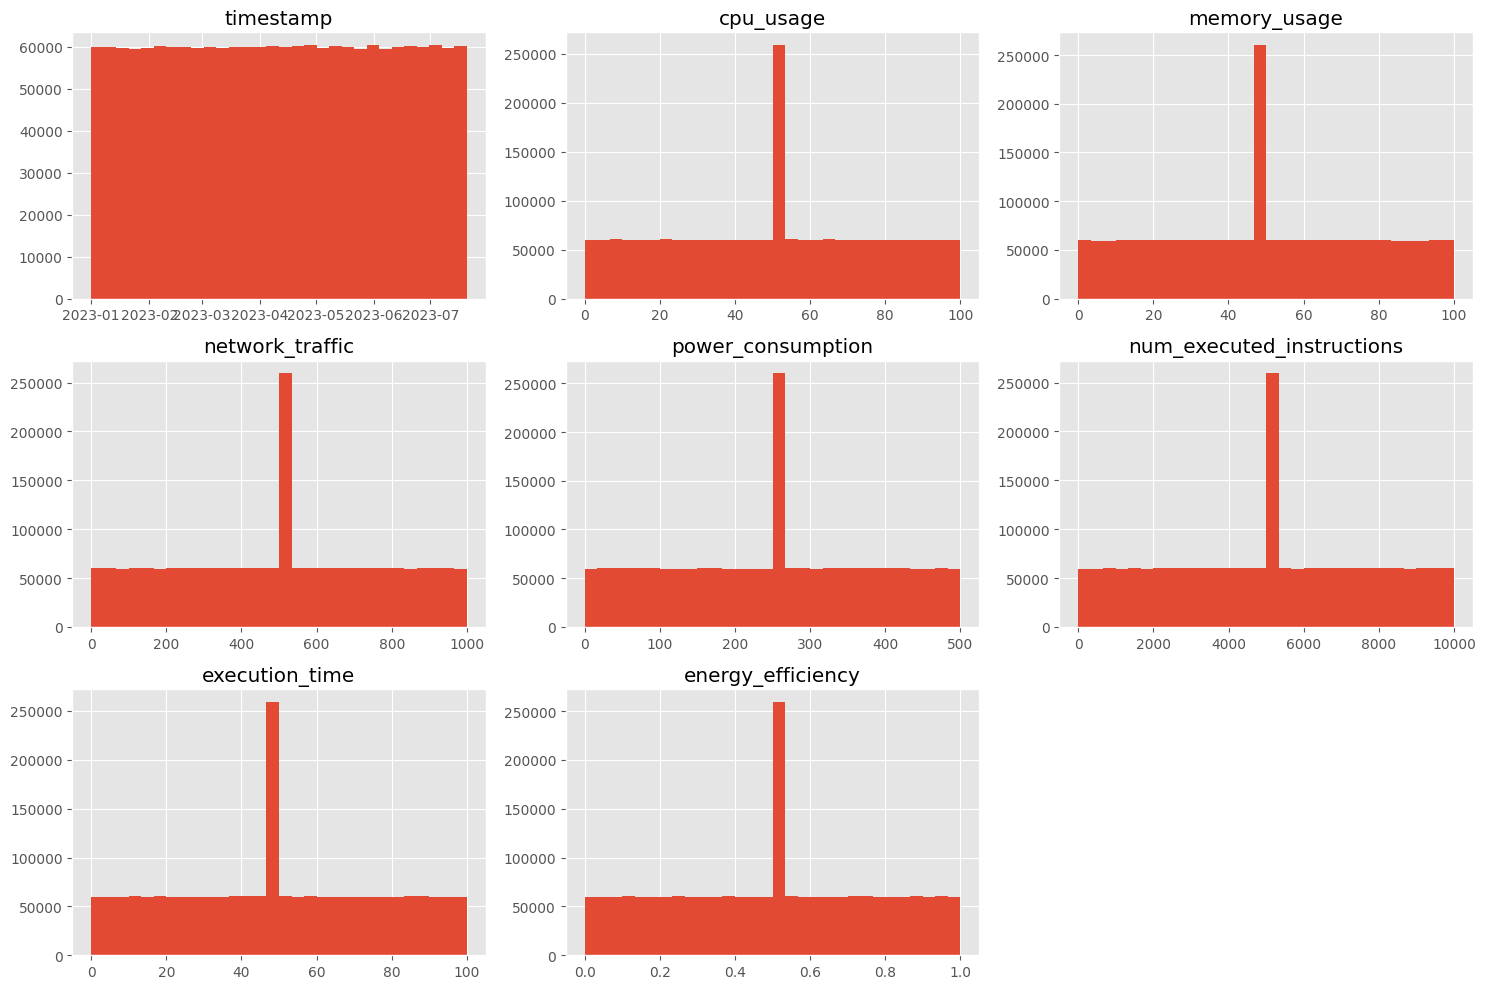

In [15]:
import matplotlib.pyplot as plt

df_clean.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

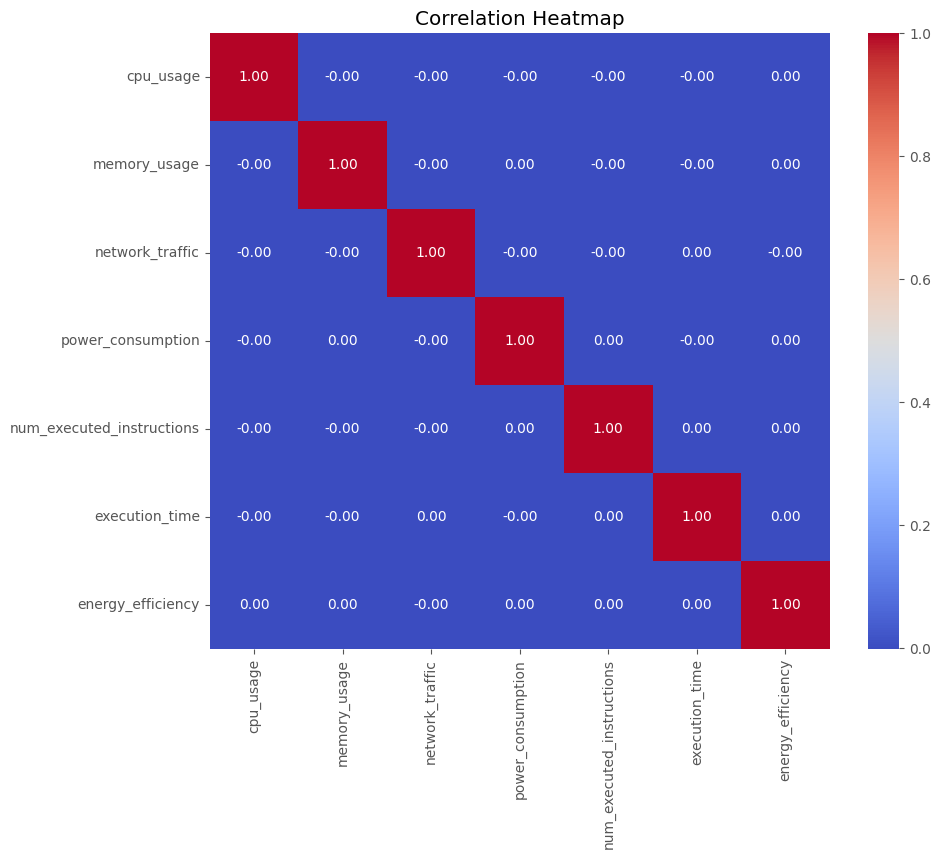

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

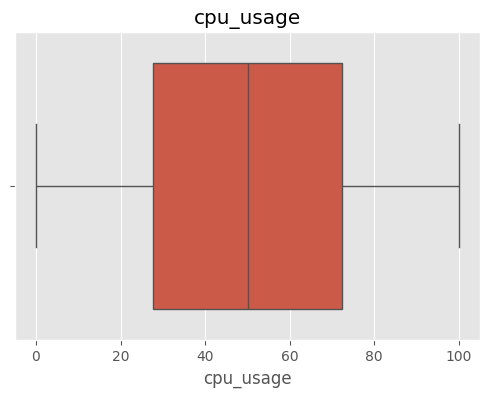

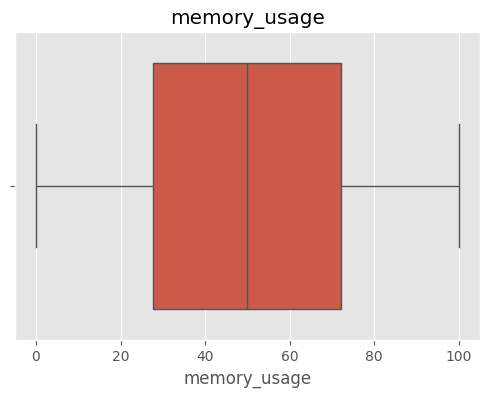

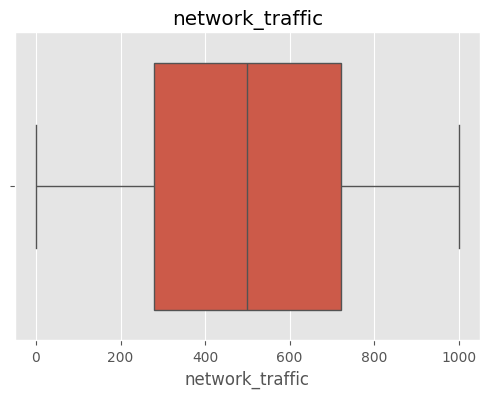

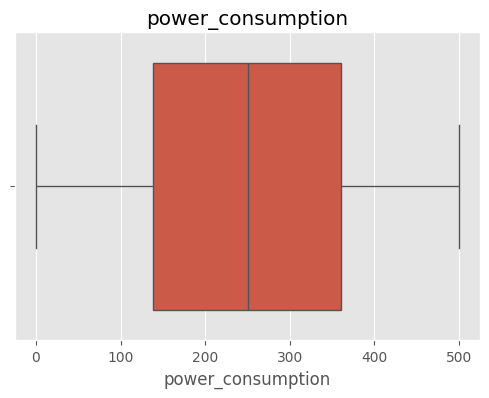

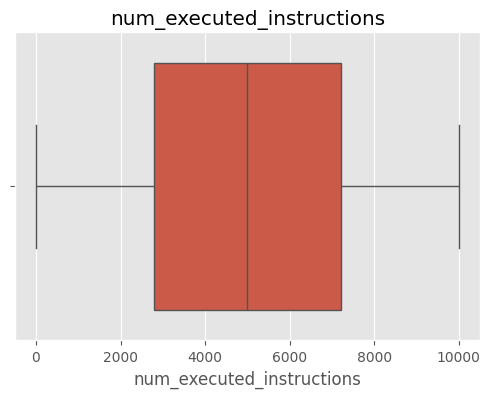

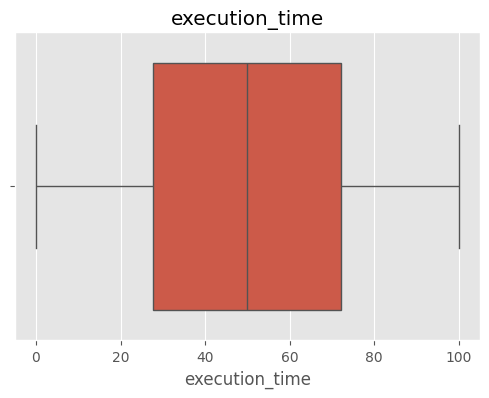

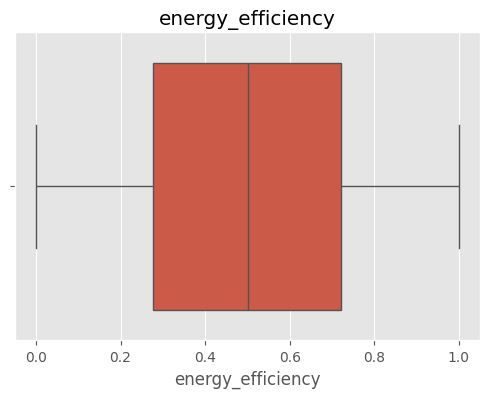

In [17]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

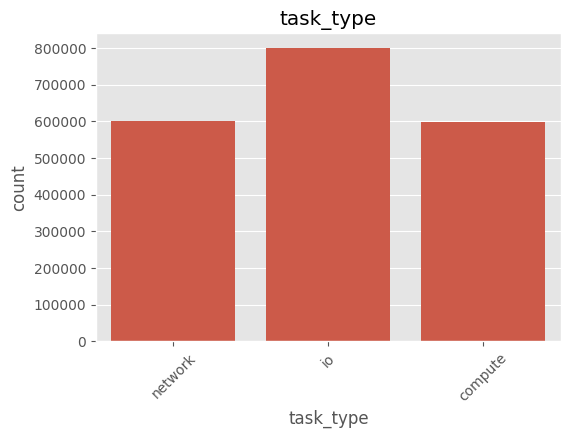

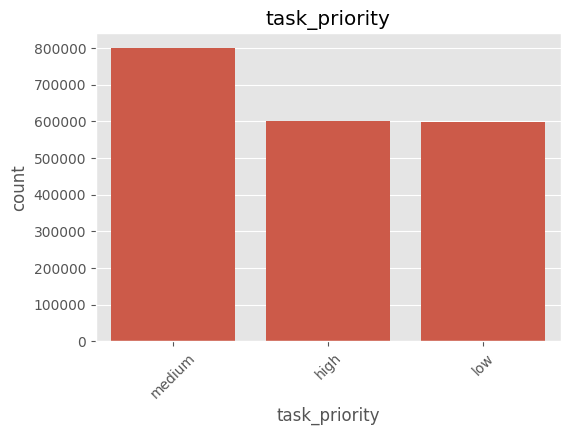

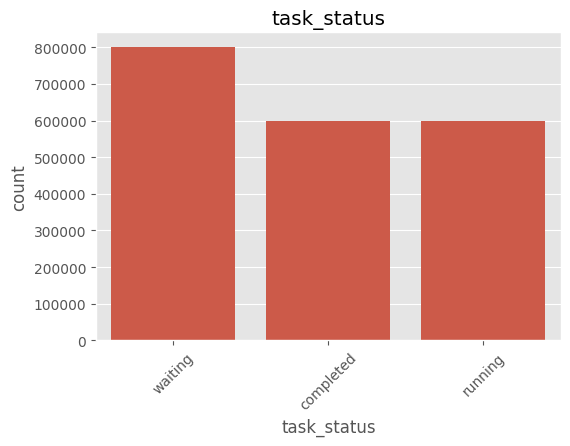

In [18]:
categorical_features = [
    "task_type",
    "task_priority",
    "task_status"
]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df_clean, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

In [19]:
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

cpu_usage: 0 outliers
memory_usage: 0 outliers
network_traffic: 0 outliers
power_consumption: 0 outliers
num_executed_instructions: 0 outliers
execution_time: 0 outliers
energy_efficiency: 0 outliers


In [20]:
# Create a copy for feature engineering
df_features = df_clean.copy()

print(df_features.head())

                                  vm_id           timestamp  cpu_usage  \
0  c5215826-6237-4a33-9312-72c1df909881 2023-01-25 09:10:54  54.881350   
1  29690bc6-1f34-403b-b509-a1ecb1834fb8 2023-01-26 04:46:34  71.518937   
2  2e55abc3-5bad-46cb-b445-a577f5e9bf2a 2023-01-13 23:39:47  50.054758   
3  e672e32f-c134-4fbc-992b-34eb63bef6bf 2023-02-09 11:45:49  54.488318   
4  f38b8b50-6926-4533-be4f-89ad11624071 2023-06-14 08:27:26  42.365480   

   memory_usage  network_traffic  power_consumption  \
0     78.950861       164.775973         287.808986   
1     29.901883       500.007595         362.273569   
2     92.709195       203.674847         231.467903   
3     88.100960       500.007595         195.639954   
4     49.976089       500.007595         359.451537   

   num_executed_instructions  execution_time  energy_efficiency task_type  \
0                     7527.0       69.345575           0.553589   network   
1                     5348.0       41.396040           0.349856       

In [21]:
# Convert to datetime (if not already)
df_features["timestamp"] = pd.to_datetime(df_features["timestamp"])

# Extract useful features
df_features["year"] = df_features["timestamp"].dt.year
df_features["month"] = df_features["timestamp"].dt.month
df_features["day"] = df_features["timestamp"].dt.day
df_features["hour"] = df_features["timestamp"].dt.hour
df_features["day_of_week"] = df_features["timestamp"].dt.dayofweek

# Remove original timestamp
df_features.drop("timestamp", axis=1, inplace=True)

df_features.head()

,vm_id,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status,year,month,day,hour,day_of_week
0,c5215826-6237-4a33-9312-72c1df909881,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting,2023.0,1.0,25.0,9.0,2.0
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,71.518937,29.901883,500.007595,362.273569,5348.0,41.396040,0.349856,io,high,completed,2023.0,1.0,26.0,4.0,3.0
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,50.054758,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed,2023.0,1.0,13.0,23.0,4.0
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,54.488318,88.100960,500.007595,195.639954,5876.0,16.456670,0.529511,compute,high,completed,2023.0,2.0,9.0,11.0,3.0
4,f38b8b50-6926-4533-be4f-89ad11624071,42.365480,49.976089,500.007595,359.451537,3361.0,55.307992,0.351907,io,medium,waiting,2023.0,6.0,14.0,8.0,2.0


In [22]:
df_features.drop("vm_id", axis=1, inplace=True)

print(df_features.head())

   cpu_usage  memory_usage  network_traffic  power_consumption  \
0  54.881350     78.950861       164.775973         287.808986   
1  71.518937     29.901883       500.007595         362.273569   
2  50.054758     92.709195       203.674847         231.467903   
3  54.488318     88.100960       500.007595         195.639954   
4  42.365480     49.976089       500.007595         359.451537   

   num_executed_instructions  execution_time  energy_efficiency task_type  \
0                     7527.0       69.345575           0.553589   network   
1                     5348.0       41.396040           0.349856        io   
2                     5483.0       24.602549           0.796277        io   
3                     5876.0       16.456670           0.529511   compute   
4                     3361.0       55.307992           0.351907        io   

  task_priority task_status    year  month   day  hour  day_of_week  
0        medium     waiting  2023.0    1.0  25.0   9.0          2.0  


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = [
    "task_type",
    "task_priority",
    "task_status"
]

for col in categorical_columns:
    le = LabelEncoder()
    df_features[col] = le.fit_transform(df_features[col])
    label_encoders[col] = le

print(df_features.head())

   cpu_usage  memory_usage  network_traffic  power_consumption  \
0  54.881350     78.950861       164.775973         287.808986   
1  71.518937     29.901883       500.007595         362.273569   
2  50.054758     92.709195       203.674847         231.467903   
3  54.488318     88.100960       500.007595         195.639954   
4  42.365480     49.976089       500.007595         359.451537   

   num_executed_instructions  execution_time  energy_efficiency  task_type  \
0                     7527.0       69.345575           0.553589          2   
1                     5348.0       41.396040           0.349856          1   
2                     5483.0       24.602549           0.796277          1   
3                     5876.0       16.456670           0.529511          0   
4                     3361.0       55.307992           0.351907          1   

   task_priority  task_status    year  month   day  hour  day_of_week  
0              2            2  2023.0    1.0  25.0   9.0      

In [24]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 15 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   cpu_usage                  float64
 1   memory_usage               float64
 2   network_traffic            float64
 3   power_consumption          float64
 4   num_executed_instructions  float64
 5   execution_time             float64
 6   energy_efficiency          float64
 7   task_type                  int64  
 8   task_priority              int64  
 9   task_status                int64  
 10  year                       float64
 11  month                      float64
 12  day                        float64
 13  hour                       float64
 14  day_of_week                float64
dtypes: float64(12), int64(3)
memory usage: 228.9 MB


In [25]:
df_features.to_csv(
    "cloud_performance_features.csv",
    index=False
)

print("Feature engineered dataset saved successfully!")

Feature engineered dataset saved successfully!


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [27]:
df_features.to_csv(
    "/content/drive/MyDrive/cloud_performance_features.csv",
    index=False
)